# **Week 4: Machine Learning in Astronomy**

## **Part 1 — Supervised Classification with Decision Trees and k-Nearest Neighbors**

Machine learning (ML) lets us learn patterns from examples and use those patterns to classify new observations. In this notebook, we will ask a deliberately simplified astronomy question: **Can a few measured properties help a model reproduce a catalog's exoplanet-habitability label?**

> **Scientific caution:** A catalog label is a model-dependent proxy, not evidence that life exists. A useful classifier can reproduce labels while still missing important physics or inheriting bias from its training data.

### Source and license

This workshop notebook is reformatted from a supplied ASTRO 416 notebook. That source says it accompanies Chapter 2 of Viviana Acquaviva's [*Machine Learning for Physics and Astronomy*](https://books.google.com/books?id=SE2zEAAAQBAJ) (Princeton University Press, 2023), identifies **Viviana Acquaviva (2023)** as copyright holder, and says it was modified for University of Michigan ASTRO 416 by [Lía Corrales](https://sites.lsa.umich.edu/liacorrales/teaching/). It uses the [BSD 3-Clause License](https://opensource.org/license/bsd-3-clause/). The data are a teaching selection from the [Planetary Habitability Laboratory's Habitable Exoplanets Catalog](https://phl.upr.edu/projects/habitable-exoplanets-catalog).

### **Learning goals**

By the end of this notebook, you should be able to:

- distinguish **features**, **targets**, **training data**, and **test data**;
- follow the standard scikit-learn workflow: create a model, call `.fit()`, then call `.predict()`;
- explain how a decision tree and k-nearest neighbors (kNN) make classifications;
- evaluate training and test accuracy without mixing the two datasets;
- explain why distance-based methods need feature scaling; and
- recognize overfitting, extrapolation, and the limits of a very small learning set.

In [1]:
# Libraries used throughout the notebook
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn import metrics, tree
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
FEATURES = ['S_MASS', 'P_PERIOD', 'P_DISTANCE']
FEATURE_LABELS = ['Host-star mass (solar masses)', 'Orbital period (days)', 'Orbital distance (AU)']

plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', 20)

# **1. From scientific inference to supervised learning**

In traditional scientific inference, we often begin with a physical model and estimate its parameters from data. In supervised machine learning, we begin with examples whose answers are already known and learn a rule that predicts those answers.

The vocabulary is simple:

- An **instance** (or sample) is one row—in this case, one planet.
- A **feature** is an input measurement used by the model.
- The **target** (or label) is the value we want to predict.
- The **training set** teaches the model.
- The **test set** is held back until evaluation so that it represents unseen data.

This split is crucial. Evaluating only on the training set is like grading students with the answer sheet they memorized.

# **2. Load and inspect the small exoplanet learning set**

Keep `HPLearningSet.csv` in the same directory as this notebook. The fallback path also allows the notebook to run from the repository root.

In [2]:
data_candidates = [
    Path('HPLearningSet.csv'),
    Path('Week4_ML_Intro') / 'HPLearningSet.csv',
]
data_path = next((path for path in data_candidates if path.exists()), None)

if data_path is None:
    raise FileNotFoundError('Could not find HPLearningSet.csv beside the notebook or in Week4_ML_Intro/.')

learning_set = pd.read_csv(data_path)
learning_set = learning_set.drop(columns=['Unnamed: 0'], errors='ignore')

print(f'Dataset shape: {learning_set.shape[0]} planets × {learning_set.shape[1]} columns')
learning_set.head()

Dataset shape: 18 planets × 5 columns


,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0


The three selected features describe the host star and the planet's orbit:

- `S_MASS`: host-star mass in solar masses;
- `P_PERIOD`: orbital period in days;
- `P_DISTANCE`: mean orbital distance in astronomical units (AU).

`P_HABITABLE` is the target: `0` means *not labeled habitable* and `1` means *labeled habitable* in this teaching dataset. `P_NAME` identifies the planet but should not be used as a numerical predictor.

In [3]:
display(learning_set.describe(include='all'))
print('\nTarget counts:')
print(learning_set['P_HABITABLE'].value_counts().sort_index())

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
count,18,18.000000,18.000000,18.000000,18.000000
unique,18,NaN,NaN,NaN,NaN
top,Kepler-736 b,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN
mean,NaN,0.636667,95.878659,0.274841,0.444444
std,NaN,0.327755,255.167845,0.496635,0.511310
min,NaN,0.090000,3.601472,0.025200,0.000000
25%,NaN,0.440000,6.926365,0.056170,0.000000
50%,NaN,0.615000,14.716330,0.112745,0.000000
75%,NaN,0.857500,55.993541,0.252982,1.000000



Target counts:
P_HABITABLE
0    10
1     8
Name: count, dtype: int64


In [4]:
# X contains features; y contains the target.
X = learning_set[FEATURES]
y = learning_set['P_HABITABLE']

display(X.head())
display(y.head().rename('target'))

,S_MASS,P_PERIOD,P_DISTANCE
0,0.86,3.601472,0.043718
1,0.85,16.080661,0.118082
2,1.19,7.638460,0.080420
3,0.61,112.305300,0.409327
4,0.98,12.992073,0.107408


0    0
1    0
2    0
3    1
4    0
Name: target, dtype: int64

# **3. Split the data before fitting**

We reserve five planets for testing. `stratify=y` keeps both target classes represented as evenly as this tiny dataset allows. `random_state` makes the random split reproducible.

> With only 18 planets, every individual object matters. Scores from one split should be treated as a demonstration, not a publishable performance estimate.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=5,
    random_state=RANDOM_STATE,
    stratify=y,
)

print('Training set:', X_train.shape)
print('Test set:    ', X_test.shape)
print('\nTraining target counts:')
print(y_train.value_counts().sort_index())
print('\nTest target counts:')
print(y_test.value_counts().sort_index())

Training set: (13, 3)
Test set:     (5, 3)

Training target counts:
P_HABITABLE
0    7
1    6
Name: count, dtype: int64

Test target counts:
P_HABITABLE
0    3
1    2
Name: count, dtype: int64


# **4. Decision trees**

A decision tree asks a sequence of yes/no questions such as “Is the orbital distance below this value?” Each split is chosen to make the resulting groups more uniform in their labels. A leaf at the bottom returns the majority class among the training examples that reach it.

Trees are interpretable and do not require feature scaling, but an unrestricted tree can keep splitting until it memorizes a small training set. That is **overfitting**: excellent training performance but weaker performance on new data.

In [6]:
dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_model.fit(X_train, y_train)

dt_train_prediction = dt_model.predict(X_train)
dt_test_prediction = dt_model.predict(X_test)

print('Training accuracy:', metrics.accuracy_score(y_train, dt_train_prediction))
print('Test accuracy:    ', metrics.accuracy_score(y_test, dt_test_prediction))

Training accuracy: 1.0
Test accuracy:     0.6


The diagram below shows the learned questions. At each node, `samples` is the number of training planets reaching that point, and `value` gives the class counts. A pure leaf contains examples from only one class.

The **Gini impurity** is defined as:

$$
G = 1 - \sum_{i=1}^{n} p_i^2
$$

where \(p_i\) is the proportion of samples belonging to class \(i\).

**Properties:**

- Lower values indicate cleaner, more homogeneous nodes.
- A node is pure when all samples belong to the same class, giving \(G = 0\).
- Higher values indicate a more even mixture of classes.
- The measure can favor splits involving the dominant class.


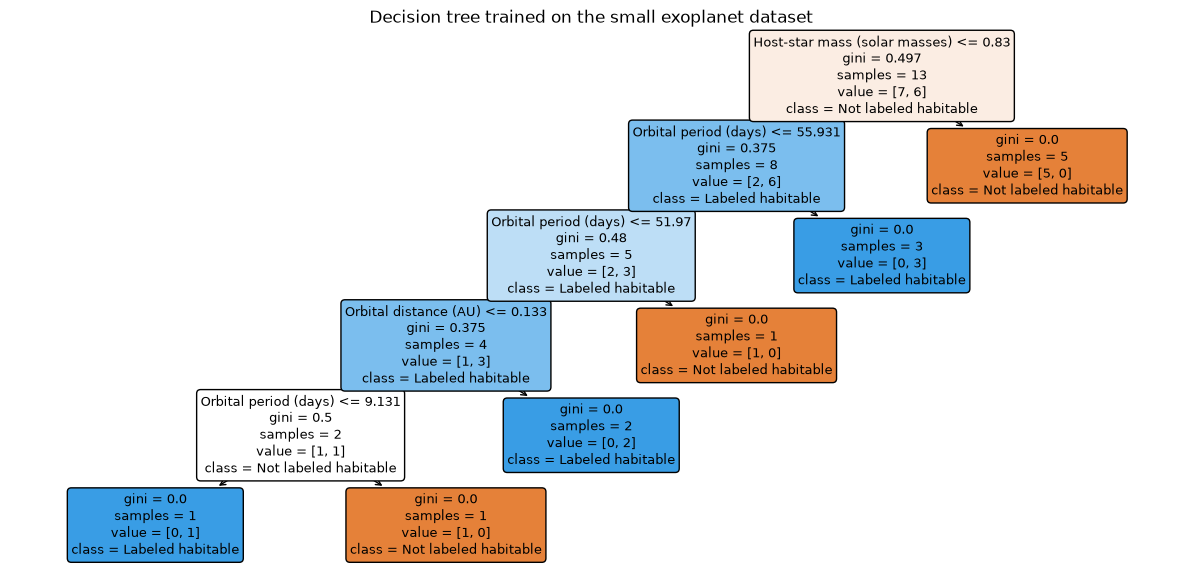

In [7]:
fig, ax = plt.subplots(figsize=(15, 7))
tree.plot_tree(
    dt_model,
    feature_names=FEATURE_LABELS,
    class_names=['Not labeled habitable', 'Labeled habitable'],
    filled=True,
    rounded=True,
    ax=ax,
)
ax.set_title('Decision tree trained on the small exoplanet dataset')
plt.show()

### **Hands-on check: sensitivity to the split**

Because this dataset is small, changing which five planets are held out can change the result. The loop below repeats the same procedure with several reproducible splits. This is a preview of cross-validation, which the next notebook treats carefully.

In [8]:
split_results = []

for seed in range(10):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=5, random_state=seed, stratify=y
    )
    model = DecisionTreeClassifier(random_state=RANDOM_STATE)
    model.fit(X_tr, y_tr)
    split_results.append({
        'split_seed': seed,
        'training_accuracy': model.score(X_tr, y_tr),
        'test_accuracy': model.score(X_te, y_te),
    })

split_results = pd.DataFrame(split_results)
display(split_results)
print('Mean test accuracy:', split_results['test_accuracy'].mean().round(3))
print('Test-score range:  ', tuple(split_results['test_accuracy'].agg(['min', 'max']).round(3)))

,split_seed,training_accuracy,test_accuracy
0,0,1.0,0.8
1,1,1.0,0.6
2,2,1.0,0.4
3,3,1.0,0.8
4,4,1.0,0.6
5,5,1.0,0.6
6,6,1.0,0.8
7,7,1.0,0.6
8,8,1.0,0.8
9,9,1.0,0.6


Mean test accuracy: 0.66
Test-score range:   (0.4, 0.8)


# **5. k-Nearest Neighbors (kNN)**

kNN classifies a new object by finding the `k` closest training examples and taking a majority vote. With `k=3`, two nearby votes are enough to set the class.

Fitting kNN mostly means storing the training data. The important assumptions are hidden in the word “closest”:

1. Which features define distance?
2. Are the features measured on comparable scales?
3. Is Euclidean distance scientifically meaningful for this problem?

We begin with two features so that we can draw the decision regions.

In [9]:
TWO_FEATURES = ['S_MASS', 'P_PERIOD']

knn_unscaled = KNeighborsClassifier(n_neighbors=3)
X_train_2d = X_train[TWO_FEATURES].to_numpy()
X_test_2d = X_test[TWO_FEATURES].to_numpy()
knn_unscaled.fit(X_train_2d, y_train)

print('Unscaled training accuracy:', knn_unscaled.score(X_train_2d, y_train))
print('Unscaled test accuracy:    ', knn_unscaled.score(X_test_2d, y_test))

distances, neighbor_indices = knn_unscaled.kneighbors(X_test_2d)
display(pd.DataFrame(distances, index=X_test.index, columns=['neighbor 1', 'neighbor 2', 'neighbor 3']))

Unscaled training accuracy: 0.7692307692307693
Unscaled test accuracy:     0.8


,neighbor 1,neighbor 2,neighbor 3
12,0.097996,1.440376,2.945788
6,0.651779,1.067561,3.024662
7,1.430516,1.779253,2.876708
4,0.674127,3.091323,3.557923
15,7.280278,7.531226,15.201981


Orbital periods vary by tens or hundreds of days, while stellar masses vary by roughly one solar mass. Without scaling, the period dominates the Euclidean distance. A one-day difference can count more than a physically substantial difference in stellar mass simply because the numerical units are larger.

In [10]:
def plot_decision_regions(model, X_train_2d, X_test_2d, y_train_values, y_test_values,
                          x_label, y_label, title):
    # Plot the predicted class across a two-feature plane.
    X_train_array = np.asarray(X_train_2d)
    X_test_array = np.asarray(X_test_2d)
    all_points = np.vstack([X_train_array, X_test_array])

    padding = 0.08 * np.maximum(np.ptp(all_points, axis=0), 1e-6)
    x_min, y_min = all_points.min(axis=0) - padding
    x_max, y_max = all_points.max(axis=0) + padding
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5], cmap='coolwarm', alpha=0.22)
    train_plot = ax.scatter(
        X_train_array[:, 0], X_train_array[:, 1], c=y_train_values,
        cmap='coolwarm', edgecolor='black', marker='o', s=90, label='Training planets'
    )
    ax.scatter(
        X_test_array[:, 0], X_test_array[:, 1], c=y_test_values,
        cmap='coolwarm', edgecolor='black', marker='*', s=220, label='Test planets'
    )
    legend = ax.legend(*train_plot.legend_elements(), title='Catalog label', loc='upper right')
    ax.add_artist(legend)
    ax.legend(loc='lower right')
    ax.set(xlabel=x_label, ylabel=y_label, title=title)
    plt.show()

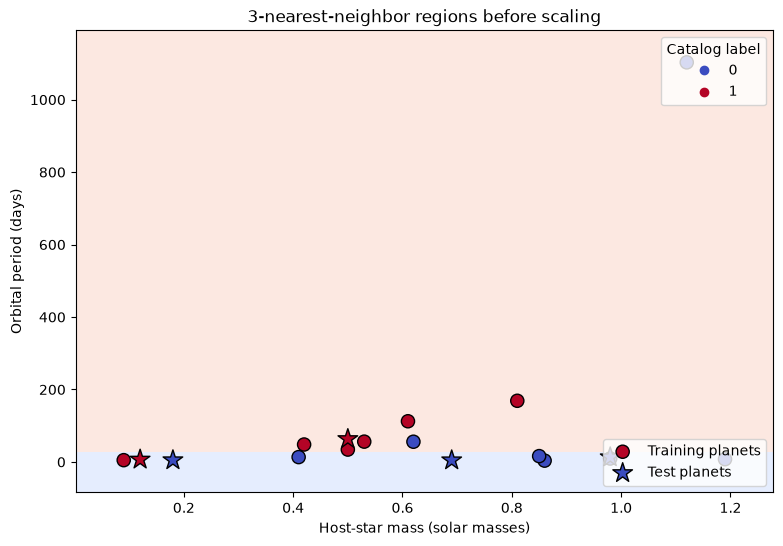

In [11]:
plot_decision_regions(
    knn_unscaled,
    X_train_2d,
    X_test_2d,
    y_train,
    y_test,
    'Host-star mass (solar masses)',
    'Orbital period (days)',
    '3-nearest-neighbor regions before scaling',
)

# **6. Scale distance-based features without leaking information**

`RobustScaler` subtracts the training median and divides by the training interquartile range (the span from the 25th to the 75th percentile). It is less sensitive to extreme values than standardizing with a mean and standard deviation.

The scaler is fitted **only on the training set**. Fitting it on the complete dataset would let information from the test set influence model preparation—a subtle form of **data leakage**.

In [12]:
scaler_2d = RobustScaler()
X_train_scaled_2d = scaler_2d.fit_transform(X_train[TWO_FEATURES])
X_test_scaled_2d = scaler_2d.transform(X_test[TWO_FEATURES])

knn_scaled_2d = KNeighborsClassifier(n_neighbors=3)
knn_scaled_2d.fit(X_train_scaled_2d, y_train)

print('Scaled training accuracy:', knn_scaled_2d.score(X_train_scaled_2d, y_train))
print('Scaled test accuracy:    ', knn_scaled_2d.score(X_test_scaled_2d, y_test))

scaled_distances, _ = knn_scaled_2d.kneighbors(X_test_scaled_2d)
display(pd.DataFrame(scaled_distances, index=X_test.index,
                     columns=['neighbor 1', 'neighbor 2', 'neighbor 3']))

Scaled training accuracy: 0.7692307692307693
Scaled test accuracy:     0.8


,neighbor 1,neighbor 2,neighbor 3
12,0.250001,0.664280,1.088256
6,0.472763,0.507529,0.799833
7,0.091654,0.818135,1.208692
4,0.076314,0.367138,0.389463
15,0.176999,0.370404,0.394590


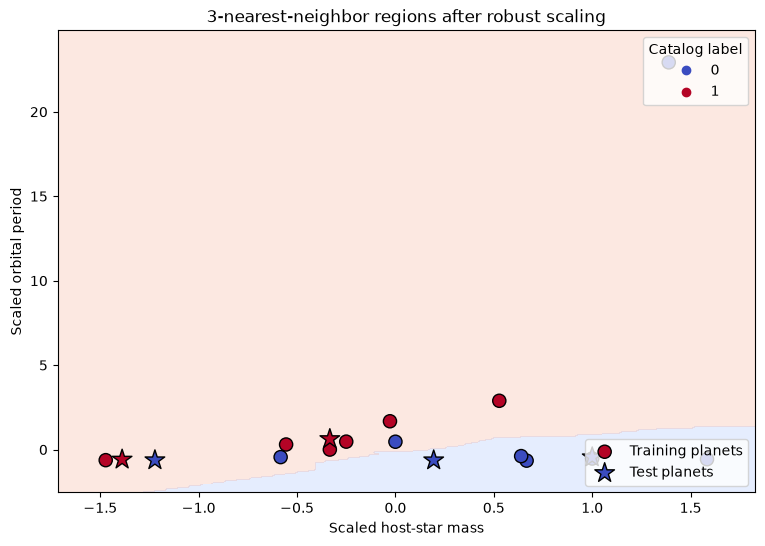

In [13]:
plot_decision_regions(
    knn_scaled_2d,
    X_train_scaled_2d,
    X_test_scaled_2d,
    y_train,
    y_test,
    'Scaled host-star mass',
    'Scaled orbital period',
    '3-nearest-neighbor regions after robust scaling',
)

For routine work, a scikit-learn `Pipeline` keeps scaling and classification together. During later cross-validation, each training fold gets its own fitted scaler automatically, which prevents leakage.

In [14]:
knn_all_features = make_pipeline(
    RobustScaler(),
    KNeighborsClassifier(n_neighbors=3),
)
knn_all_features.fit(X_train, y_train)

knn_test_prediction = knn_all_features.predict(X_test)
comparison = pd.DataFrame({
    'true_label': y_test,
    'predicted_label': knn_test_prediction,
})
display(comparison)
print('All-feature training accuracy:', knn_all_features.score(X_train, y_train))
print('All-feature test accuracy:    ', knn_all_features.score(X_test, y_test))

,true_label,predicted_label
12,0,1
6,0,0
7,1,1
4,0,0
15,1,1


All-feature training accuracy: 0.7692307692307693
All-feature test accuracy:     0.8


### **Hands-on exercise: what does `k` change?**

A very small `k` creates flexible, jagged decision regions and can follow noise. A larger `k` averages over more neighbors and creates a smoother—but potentially too simple—model. Run the cell, then change the candidate values.

In [15]:
k_results = []

for k in [1, 3, 5, 7, 9]:
    model = make_pipeline(RobustScaler(), KNeighborsClassifier(n_neighbors=k))
    model.fit(X_train, y_train)
    k_results.append({
        'k': k,
        'training_accuracy': model.score(X_train, y_train),
        'test_accuracy': model.score(X_test, y_test),
    })

display(pd.DataFrame(k_results))

,k,training_accuracy,test_accuracy
0,1,1.000000,0.8
1,3,0.769231,0.8
2,5,0.769231,0.8
3,7,0.692308,0.8
4,9,0.615385,0.6


### **Question: Solar System planets and extrapolation**

The values below let us apply the model outside its small training sample. Earth is the only positive label in this demonstration. Do not interpret the predictions as scientific claims: several Solar System periods and distances lie outside the training range, and kNN cannot discover missing atmospheric or geological physics.

In [16]:
solar_system = pd.DataFrame({
    'P_NAME': ['Mercury', 'Venus', 'Earth', 'Mars', 'Jupiter'],
    'S_MASS': [1.0, 1.0, 1.0, 1.0, 1.0],
    'P_PERIOD': [87.97, 224.70, 365.25, 686.98, 4332.59],
    'P_DISTANCE': [0.387, 0.723, 1.000, 1.524, 5.203],
    'demonstration_label': [0, 0, 1, 0, 0],
})

solar_model = make_pipeline(RobustScaler(), KNeighborsClassifier(n_neighbors=3))
solar_model.fit(X, y)
solar_system['predicted_label'] = solar_model.predict(solar_system[FEATURES])

display(solar_system)
print('Demonstration accuracy:', metrics.accuracy_score(
    solar_system['demonstration_label'], solar_system['predicted_label']
))

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,demonstration_label,predicted_label
0,Mercury,1.0,87.97,0.387,0,1
1,Venus,1.0,224.70,0.723,0,1
2,Earth,1.0,365.25,1.000,1,1
3,Mars,1.0,686.98,1.524,0,1
4,Jupiter,1.0,4332.59,5.203,0,1


Demonstration accuracy: 0.2


# **Conclusion**

- Supervised learning maps measured **features** to a known **target**.
- Decision trees make interpretable threshold cuts but can overfit.
- kNN votes among nearby examples, so both the feature choices and their scales matter.
- Preprocessing must learn from training data only; a pipeline makes that rule easier to follow.
- A single test split is unstable for a tiny dataset. The next notebook uses a larger catalog, class-aware metrics, and cross-validation.